# 22DM015 Final Project — Financial PhraseBank
**Part 3 — Full-dataset SOA comparison**

Part 3 retains only the "BERT" model, and we decided not to freeze any layers.‍ This is because we learned from Part 2 that training all (or not freezing any layers) is better overall.‍

## Preparations

In [1]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- Reproducibility seed (required by the assignment) ---
import os, random, sys
import numpy as np
import pandas as pd

import logging, warnings
# Tell transformers to skip its TensorFlow/Flax/Keras probe (we use PyTorch only).
os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('USE_FLAX', '0')
os.environ.setdefault('TRANSFORMERS_NO_ADVISORY_WARNINGS', '1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
# On Apple Silicon, let any op not yet implemented for the MPS backend fall back to CPU
# instead of erroring out. No-op on CUDA/CPU machines.
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('torch.distributed.elastic.multiprocessing.redirects').setLevel(logging.ERROR)
logging.getLogger('torchao').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message=r'.*Skipping import of cpp extensions.*')

import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed, EarlyStoppingCallback)
import transformers
transformers.logging.set_verbosity_error()       # hide the per-load model LOAD REPORTs
transformers.logging.disable_progress_bar()
import datasets.utils.logging as _ds_logging
_ds_logging.disable_progress_bar()


# Make the shared helpers importable (they live in the repo root, one level up).
sys.path.append(os.path.abspath('..'))
import data_utils as du
import eval_utils as eu

SEED = du.SEED
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

splits = du.load_splits()            # identical train/val/test for everyone
train, val, test = splits['train'], splits['val'], splits['test']
# Part 3 keeps val HELD OUT (not folded into train): every Part 3 training early-stops on
# val and keeps the best-on-val checkpoint, so val must stay separate. The full-data curve
# point is therefore 1584, and the headline numbers are still measured on test only.
for k, v in splits.items():
    print(f'{k:11s} {len(v):5d}', dict(v['label_name'].value_counts()))

train        1584 {'neutral': np.int64(973), 'positive': np.int64(399), 'negative': np.int64(212)}
val           227 {'neutral': np.int64(140), 'positive': np.int64(57), 'negative': np.int64(30)}
test          453 {'neutral': np.int64(278), 'positive': np.int64(114), 'negative': np.int64(61)}


In [7]:
# watermark: AGLLM (AI-assisted content disclosure)
# Shared training helpers (mirrors bert_part2.ipynb so Part 3 stays runnable on its own).


# Pick the best available accelerator: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU.
# The HF Trainer moves the model/batches onto this device automatically; we only use DEVICE
# to toggle the CPU-thread / pin-memory settings in TrainingArguments below.
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'torch {torch.__version__} | device: {DEVICE}')

if DEVICE == 'cpu':
    torch.set_num_threads(os.cpu_count() or 4)   # CPU training: use all cores
MODEL = 'bert-base-uncased'      # same as Part 2 for direct comparability
NUM_LABELS = 3
MAX_LEN = 128
EARLY_STOP_PATIENCE = 3

torch 2.12.0 | device: mps


In [8]:
# watermark: AGLLM (AI-assisted content disclosure)
tok = AutoTokenizer.from_pretrained(MODEL)


def encode(df, max_len=MAX_LEN):
    ds = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return ds.map(lambda b: tok(b['text'], truncation=True, padding='max_length', max_length=max_len),
                  batched=True)


def compute_metrics(eval_pred):
    # Same metric dict as Part 2 (eval_utils.evaluate), so 'f1_macro' (logged as
    # 'eval_f1_macro') drives best-checkpoint selection during early stopping.
    preds = eval_pred.predictions.argmax(-1)
    return eu.evaluate(eval_pred.label_ids, preds)


def train_bert(train_df, out_dir, *, val_df=None, epochs=20, batch=8, max_len=MAX_LEN,
               lr=2e-5, log_epochs=False, patience=EARLY_STOP_PATIENCE):
    """Full fine-tuning protocol, matching bert_part2.ipynb's full-FT setup (Part 3 uses
    full fine-tuning only — the stronger regime in Part 2's 2a — so there is no freeze
    switch here). EARLY STOPPING on the held-out val split: evaluate macro-F1 each epoch,
    keep the best-on-val checkpoint, and stop after `patience` epochs without improvement.
    Runs on whatever DEVICE the setup detected (CUDA / MPS / CPU).

    train_df -> the (possibly subsampled) TRAINING rows; the only thing that varies across
                the data-scaling curve. All ~110M params train.
    val_df   -> defaults to the shared held-out `val`; this is what early stopping watches.
                It is never subsampled, so every curve point is selected on the same fixed
                val and scored on the same fixed test.
    lr       -> 2e-5, the Part 2 full-fine-tuning rate (small, to nudge the pretrained
                backbone).
    log_epochs -> True logs train loss each epoch so the live notebook metrics TABLE shows
                a Training-Loss column too (as in Part 2); the eval rows show either way."""
    val_df = val if val_df is None else val_df
    set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)

    args = TrainingArguments(
        output_dir=out_dir, seed=SEED,
        num_train_epochs=epochs, per_device_train_batch_size=batch,
        per_device_eval_batch_size=64, learning_rate=lr,
        eval_strategy='epoch', save_strategy='epoch', save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model='f1_macro', greater_is_better=True,
        logging_strategy='epoch' if log_epochs else 'no',
        report_to='none', disable_tqdm=False,          # keep the live notebook metrics TABLE (as Part 2)
        use_cpu=(DEVICE == 'cpu'),                     # otherwise let Trainer use CUDA/MPS
        dataloader_pin_memory=(DEVICE == 'cuda'),      # pin_memory only helps/works on CUDA
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=encode(train_df, max_len),
        eval_dataset=encode(val_df, max_len),          # early stopping watches val, never train
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
    )
    trainer.train()
    trainer.eval_max_len = max_len
    return trainer


def eval_split(trainer, df, max_len=None):
    max_len = max_len or getattr(trainer, 'eval_max_len', MAX_LEN)
    pred = trainer.predict(encode(df, max_len)).predictions.argmax(-1)
    return eu.evaluate(df['label'].values, pred)


def logged(method, full_row=False):
    """Latest TEST row for (MODEL, method) from the shared scoreboard. The eval module
    keys rows on (model, method, split, n_train_labeled) and no longer tracks person, so
    we match on MODEL + method here (each method has a single n in this notebook).
    Delete a row from results.csv to force that experiment to re-run."""
    if not eu.RESULTS_CSV.exists():
        return None
    r = pd.read_csv(eu.RESULTS_CSV)
    r = r[(r['model'] == MODEL) & (r['method'] == method) & (r['split'] == 'test')]
    if not len(r):
        return None
    row = r.iloc[-1]
    return row if full_row else {k: row[k] for k in eu.METRIC_KEYS}


def notes_kv(notes):
    """Parse the 'k=v; k=v' segments of a notes string into a dict."""
    out = {}
    for seg in str(notes).split(';'):
        if '=' in seg:
            k, v = seg.split('=', 1)
            out[k.strip()] = v.strip()
    return out


fmt = eu.fmt

## 3a.‍ Data-scaling curve (1 / 10 / 25 / 50 / 75 / 100 %)



In Part 3a, We build the curve by fine-tuning this model on stratified subsets of the training set at **1%, 10%, 25%, 50%, 75%, and 100%**.‍ Validation and test are never subsampled, so every point early-stops on the same fixed `val` and is scored on the same fixed `test`.‍

We are already using the same training hyperparameters as in Part 2: the same learning rate, batch size of 8, maximum length of 128, a maximum of 20 epochs, and early stopping (patience value of 3) on the preserved validation macro F1 score, allowing direct comparison of the two parts.‍

The combination of a 20-epoch cap and early stopping is very important here.‍ We previously experimented with a smaller fixed budget (a few epochs), we found this is not enough because patience is not met; therefore, a lower budget can cause problems.‍ However, early stopping eliminates this ambiguity: each run trains until the macro F1 value on the validation set stops improving for three consecutive epochs, reaching a plateau.‍ Therefore, each point on the curve represents a complete training run; the only change is the amount of training data.‍



In [9]:
#47 minutes M4 Macbook Air
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3a — data-scaling curve. SAME protocol as Part 2's BEST model (full fine-tuning, NO
# freezing): up to 20 epochs with early stopping on the held-out val macro-F1 (patience 3),
# lr 2e-5, batch 8, max_len 128 -- i.e. train_bert's defaults, identical to bert_part2.ipynb.
# The ONLY thing that varies across the curve is the number of TRAINING rows.
CURVE = dict(epochs=20, batch=8, max_len=128, patience=3)    # == Part 2 full-FT protocol
FRACTIONS = [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]             # increasing increments of train

curve_rows = []
for f in FRACTIONS:
    method = f'full-{int(f * 100)}%'
    sub = du.subset_by_fraction(train, f)                    # stratified subset; val/test untouched
    prev = logged(method, full_row=True)
    m = None
    if prev is not None:
        kv = notes_kv(prev['notes'])
        if (kv.get('epochs') == str(CURVE['epochs']) and kv.get('maxlen') == str(CURVE['max_len'])
                and kv.get('patience') == str(CURVE['patience'])):
            m = {k: prev[k] for k in eu.METRIC_KEYS}
            print(f"frac={f:>4}  n={len(sub):4d}  [cached]  macroF1={float(m['f1_macro']):.4f}")
        else:
            print(f"frac={f:>4}  [stale] logged row used a different protocol — retraining")
    if m is None:
        # full FT, early-stop on val; log_epochs=True keeps the live Part 2-style metrics table
        tr = train_bert(sub, '../.cache/bert_curve', lr=2e-5, log_epochs=True, **CURVE)
        m = eval_split(tr, test)
        eu.log_result(MODEL, method, len(sub), m,
                      notes=f"frac={f}; n={len(sub)}; full fine-tuning; lr=2e-5; "
                            f"epochs={CURVE['epochs']}; maxlen={CURVE['max_len']}; "
                            f"patience={CURVE['patience']}; early_stop=val_f1_macro")
        print(f"frac={f:>4}  n={len(sub):4d}  [trained] macroF1={float(m['f1_macro']):.4f}")
    curve_rows.append({'frac': f, 'n_train': len(sub), **m})

frac=0.01  n=  15  [cached]  macroF1=0.4794
frac= 0.1  n= 158  [cached]  macroF1=0.8793
frac=0.25  n= 396  [cached]  macroF1=0.9436
frac= 0.5  n= 792  [cached]  macroF1=0.9596
frac=0.75  n=1188  [cached]  macroF1=0.9598
frac= 1.0  n=1584  [cached]  macroF1=0.9580


In every run, early stopping triggered before the 20-epoch cap was reached: validation macro-F1 plateaued and the patience-3 criterion ended training on its own.‍ The cap was never the binding constraint, which confirms that 20 epochs leaves plenty of headroom and that each curve point reflects a converged model rather than one cut short.‍ Any differences along the curve therefore come from how much data the model saw, not from how long it was allowed to train.‍

## 3b Learning Curve

The six line graphs show how six performance metrics of a fine-tuned BERT model changed when the proportion of training data increased from 1% to 100%.‍

Overall, all metrics improved as more training data was provided.‍ Most of the improvement happened in the early stage, and the curves became relatively flat after 10%.‍ The minority classes (positive and negative) performed much worse at the beginning compared to the majority class (neutral).‍ In the case of F1 negative, because the negative labels are rare, the module has a worst prediction in the beginning.‍

In terms of the overall metrics, accuracy began at 0.72 with only 1% of data, while macro-F1 was considerably lower at 0.48.‍ Both figures rose significantly when 10% of data was used, reaching 0.91 and 0.88 respectively.‍ After that, the improvement slowed down, and both metrics eventually reached around 0.99 and 0.98 at 100%.‍

Regarding the per-class performance, the neutral class had a relatively high F1 score of 0.87 even at 1% and quickly improved to nearly 1.00.‍ In contrast, the negative class scored 0.00 at the beginning, which means the model completely failed to identify it.‍ However, it increased sharply to 0.90 at 10% and stabilised at approximately 0.97.‍ The positive class also followed a similar pattern, rising steadily from 0.57 to 0.97.‍

In conclusion, the model improved quickly on the neutral class (because the neutral label are major) but needed more data to handle the minority classes well, which explains why macro-F1 was lower than accuracy at the start.‍ We also see that increasing the number of data was exponentially beneficial up to a certain point (around 50% in our case) and  performance plateaus afterwards.‍  

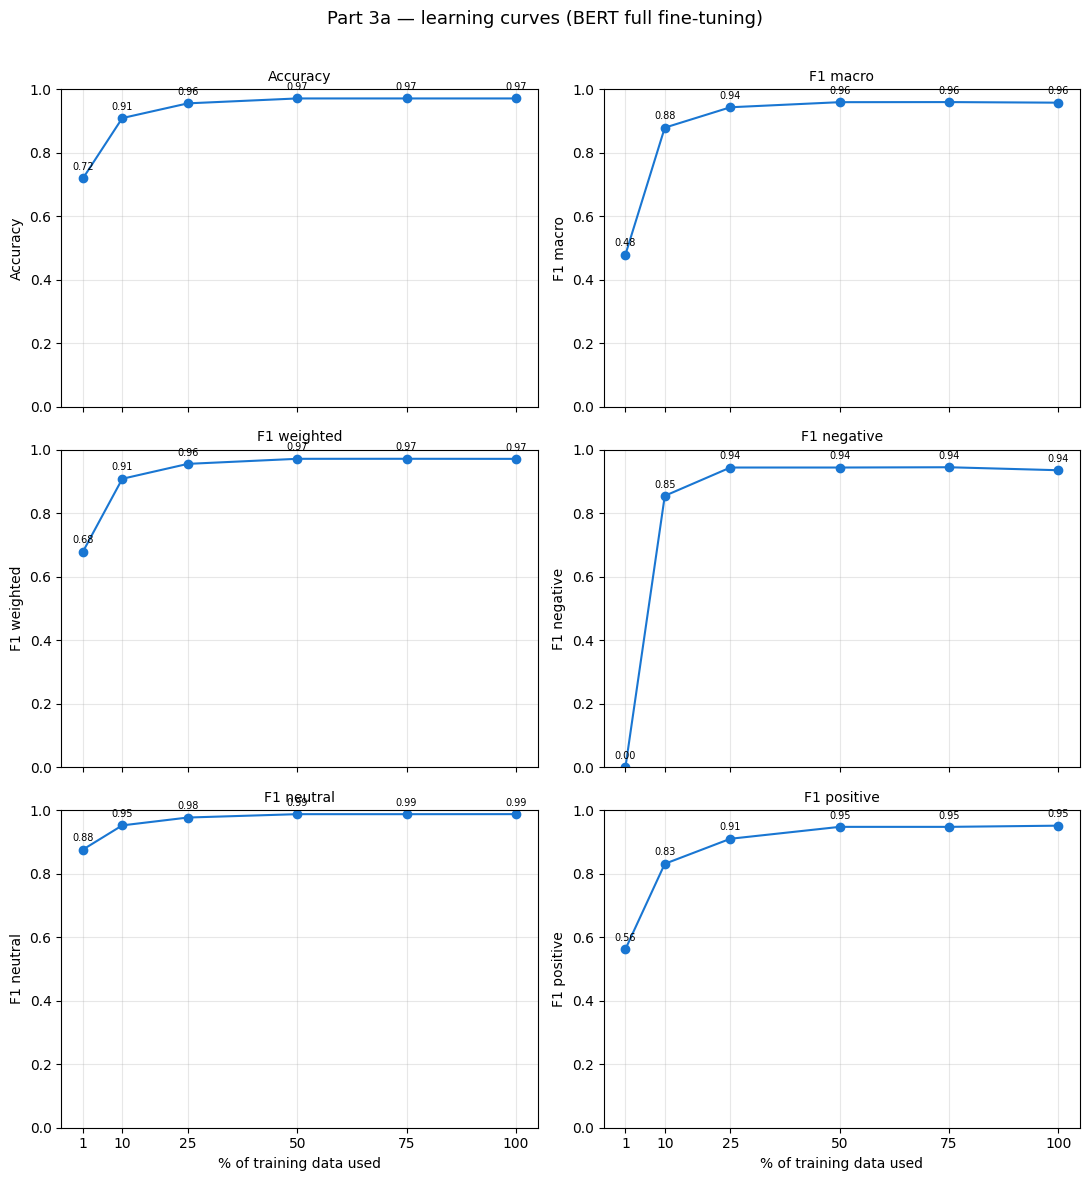

In [10]:
# watermark: AGLLM (AI-assisted content disclosure)
import matplotlib.pyplot as plt

# One panel per metric -> fills the 3x2 grid.
CURVE_METRICS = [('accuracy', 'Accuracy'), ('f1_macro', 'F1 macro'),
                 ('f1_weighted', 'F1 weighted'), ('f1_negative', 'F1 negative'),
                 ('f1_neutral', 'F1 neutral'), ('f1_positive', 'F1 positive')]


def plot_learning_curves(maxlen=None, title='Part 3a — learning curves (BERT full fine-tuning)'):
    """3x2 grid of learning curves, one panel per test metric, vs the % of training data used
    (linear x-axis). Reads the logged 'full-N%' rows from results.csv for the CURRENT curve
    protocol (matched on the maxlen recorded in notes), so it reflects whatever 3a has logged
    and ignores rows left from an older protocol."""
    maxlen = str(maxlen if maxlen is not None else CURVE['max_len'])
    res = pd.read_csv(eu.RESULTS_CSV)
    res = res[(res['model'] == MODEL) & (res['split'] == 'test')
              & res['method'].str.fullmatch(r'full-\d+%').fillna(False)]
    res = res[res['notes'].apply(lambda s: notes_kv(s).get('maxlen') == maxlen)]
    res = res.sort_values('n_train_labeled')
    if res.empty:
        print(f'[waiting] no logged full-N% rows for maxlen={maxlen} yet — run the 3a cell first')
        return res
    pct = res['method'].str.extract(r'full-(\d+)%')[0].astype(int).to_numpy()   # 1, 10, 25, 50, 75, 100

    fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True)
    for ax, (key, label) in zip(axes.ravel(), CURVE_METRICS):
        y = res[key].astype(float).to_numpy()
        ax.plot(pct, y, marker='o', color='#1976d2')
        ax.set_title(label, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xticks(pct)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        for x, yy in zip(pct, y):
            ax.annotate(f'{yy:.2f}', (x, yy), textcoords='offset points',
                        xytext=(0, 6), fontsize=7, ha='center')
    for ax in axes[-1]:
        ax.set_xlabel('% of training data used')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    return res


_ = plot_learning_curves()

## 3c.‍ Technique comparison — LLM-generated augmentation across training percentages

Part 3c requires us to incorporate the techniques from Part 2 into the full dataset setup, rather than simply matching the hyperparameters from Part 2.‍ We adopted the most effective technique from Part 2—using LLM-generated examples to augment the data.‍ Specifically, we used a fixed set of approximately 360 LLM-generated sentences and added them to each real data increment (1% + 360, 10% + 360, ..., 100% + 360), while maintaining the exact same protocol as in Part 3a (fully fine-tuned, the same learning rate, batch size 8, maximum length 128, maximum 20 epochs, and early stopping on the validation set).‍

The x-axis remains the percentage of the true labels, so this curve directly overlaps with the curve from Part 3a using only real data, thus highlighting the gains from synthetic data.‍

In [27]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3c — incorporate the LLM data-generation technique (Part 2d) into the Part 3 training
# schema: rerun the SAME percentage schedule as 3a, but add the fixed LLM-generated set to
# each real subset before training. Same protocol as 3a (full FT, lr 2e-5, maxlen 128, batch 8,
# up to 20 epochs, early-stop on val). x stays the % of REAL data so this curve overlays 3a's.
# RESUME-AWARE: a row is reused only if its notes match the current protocol AND gen-set size.
gen_3c = pd.read_csv('./llm_generated.csv')[['text', 'label']]   # fixed LLM-generated pool

aug_curve_rows = []
for f in FRACTIONS:
    method = f'llmgen-{int(f * 100)}%'
    sub = du.subset_by_fraction(train, f)                          # f% of REAL train (stratified)
    combo = pd.concat([sub[['text', 'label']], gen_3c], ignore_index=True)
    prev = logged(method, full_row=True)
    m = None
    if prev is not None:
        kv = notes_kv(prev['notes'])
        if (kv.get('epochs') == str(CURVE['epochs']) and kv.get('maxlen') == str(CURVE['max_len'])
                and kv.get('patience') == str(CURVE['patience']) and kv.get('gen') == str(len(gen_3c))):
            m = {k: prev[k] for k in eu.METRIC_KEYS}
            print(f"frac={f:>4}  real={len(sub):4d} +gen={len(gen_3c)} -> n={len(combo):4d}  [cached]  macroF1={float(m['f1_macro']):.4f}")
        else:
            print(f"frac={f:>4}  [stale] logged row used a different protocol/gen-set — retraining")
    if m is None:
        tr = train_bert(combo, '../.cache/bert_3c_llmgen', lr=2e-5, log_epochs=True, **CURVE)
        m = eval_split(tr, test)
        eu.log_result(MODEL, method, len(sub), m,                 # n = REAL labels at this %, for x-axis alignment with 3a
                      notes=f"3c llm-gen aug; frac={f}; real={len(sub)}; gen={len(gen_3c)}; n={len(combo)}; "
                            f"full fine-tuning; lr=2e-5; epochs={CURVE['epochs']}; maxlen={CURVE['max_len']}; "
                            f"patience={CURVE['patience']}; early_stop=val_f1_macro")
        print(f"frac={f:>4}  real={len(sub):4d} +gen={len(gen_3c)} -> n={len(combo):4d}  [trained] macroF1={float(m['f1_macro']):.4f}")
    aug_curve_rows.append({'frac': f, 'n_real': len(sub), 'n_total': len(combo), **m})

pd.DataFrame(aug_curve_rows)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.779184,0.582169,0.740088,0.620956,0.747538,0.417910,0.901099,0.543860
2,0.230895,0.491241,0.837004,0.776634,0.840632,0.690476,0.923636,0.715789
3,0.049093,0.587814,0.832599,0.766733,0.836545,0.682927,0.930403,0.686869
4,0.014063,0.547615,0.867841,0.819457,0.870963,0.750000,0.937729,0.770642
5,0.003337,0.642417,0.859031,0.816811,0.864888,0.742857,0.924242,0.783333
6,0.002301,0.695136,0.859031,0.818242,0.864686,0.753623,0.924242,0.776860
7,0.001765,0.754231,0.859031,0.816811,0.864888,0.742857,0.924242,0.783333


frac=0.01  real=  15 +gen=360 -> n= 375  [trained] macroF1=0.8286


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.693896,0.442222,0.841410,0.786779,0.846861,0.707692,0.925373,0.727273
2,0.195996,0.359228,0.889868,0.852540,0.891937,0.792453,0.940741,0.824427
3,0.089489,0.487265,0.894273,0.856866,0.897654,0.781250,0.943820,0.845528
4,0.035856,0.417356,0.903084,0.864967,0.905102,0.807018,0.955882,0.832000
5,0.005997,0.369504,0.925110,0.899942,0.926299,0.862069,0.959707,0.878049
6,0.002005,0.389608,0.920705,0.890927,0.921882,0.842105,0.959707,0.870968
7,0.001465,0.489694,0.907489,0.874559,0.910136,0.812500,0.951673,0.859504
8,0.000997,0.482456,0.911894,0.886324,0.914246,0.852459,0.951673,0.854839


frac= 0.1  real= 158 +gen=360 -> n= 518  [trained] macroF1=0.9019


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.619917,0.328754,0.876652,0.826499,0.872814,0.779661,0.937931,0.761905
2,0.142198,0.378498,0.894273,0.861737,0.892658,0.833333,0.937063,0.814815
3,0.044391,0.482002,0.898678,0.871197,0.901486,0.827586,0.939850,0.846154
4,0.014658,0.476325,0.911894,0.885465,0.913542,0.842105,0.948148,0.866142
5,0.008021,0.420372,0.925110,0.899216,0.926092,0.847458,0.955882,0.894309
6,0.000934,0.420798,0.929515,0.905362,0.930382,0.862069,0.959707,0.894309
7,0.000709,0.460493,0.929515,0.905362,0.930382,0.862069,0.959707,0.894309
8,0.000577,0.467344,0.929515,0.902935,0.930291,0.847458,0.959707,0.901639
9,0.000486,0.489043,0.929515,0.905362,0.930382,0.862069,0.959707,0.894309


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.458671,0.238699,0.933921,0.903815,0.932483,0.862069,0.968641,0.880734
2,0.124316,0.245286,0.942731,0.907998,0.943980,0.843750,0.985507,0.894737
3,0.061331,0.189194,0.960352,0.935961,0.961015,0.888889,0.989170,0.929825
4,0.033027,0.325418,0.929515,0.906963,0.931421,0.885246,0.966790,0.868852
5,0.005789,0.250153,0.951542,0.925579,0.952288,0.885246,0.985507,0.905983
6,0.000484,0.234742,0.964758,0.941952,0.965152,0.903226,0.992806,0.929825
7,0.000280,0.271304,0.955947,0.934175,0.956626,0.903226,0.985507,0.913793
8,0.000218,0.287494,0.951542,0.930342,0.952389,0.903226,0.981818,0.905983
9,0.003443,0.322410,0.947137,0.926544,0.948169,0.903226,0.978102,0.898305


frac=0.75  real=1188 +gen=360 -> n=1548  [trained] macroF1=0.9628


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.419864,0.169457,0.942731,0.905761,0.943877,0.830769,0.985612,0.900901
2,0.121177,0.160906,0.969163,0.949990,0.969446,0.918033,0.992806,0.939130
3,0.039493,0.168598,0.973568,0.954493,0.973849,0.920635,0.996416,0.946429
4,0.014027,0.209594,0.960352,0.936995,0.960501,0.900000,0.989247,0.921739
5,0.010001,0.267873,0.960352,0.932819,0.960430,0.885246,0.992857,0.920354
6,0.001859,0.330151,0.955947,0.934175,0.956626,0.903226,0.985507,0.913793


frac= 1.0  real=1584 +gen=360 -> n=1944  [trained] macroF1=0.9565


,frac,n_real,n_total,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,0.01,15,375,0.876380,0.828579,0.872975,0.794326,0.940141,0.751269
1,0.10,158,518,0.929360,0.901916,0.928623,0.878049,0.967972,0.859729
2,0.25,396,756,0.949227,0.932011,0.949465,0.914729,0.974638,0.906667
3,0.50,792,1152,0.964680,0.947143,0.964561,0.923077,0.987478,0.930876
4,0.75,1188,1548,0.975717,0.962774,0.975833,0.944000,0.992780,0.951542
5,1.00,1584,1944,0.969095,0.956496,0.969240,0.937500,0.985560,0.946429


Results were produced on an A100 GPU (Colab), We also tried running this on an Apple Silicon laptop, but it was too slow to handle.‍
Because training uses early stopping on a small validation set and floating-point behaviour differs across hardware, re-running on a different machine can shift each metric by one or two points.‍


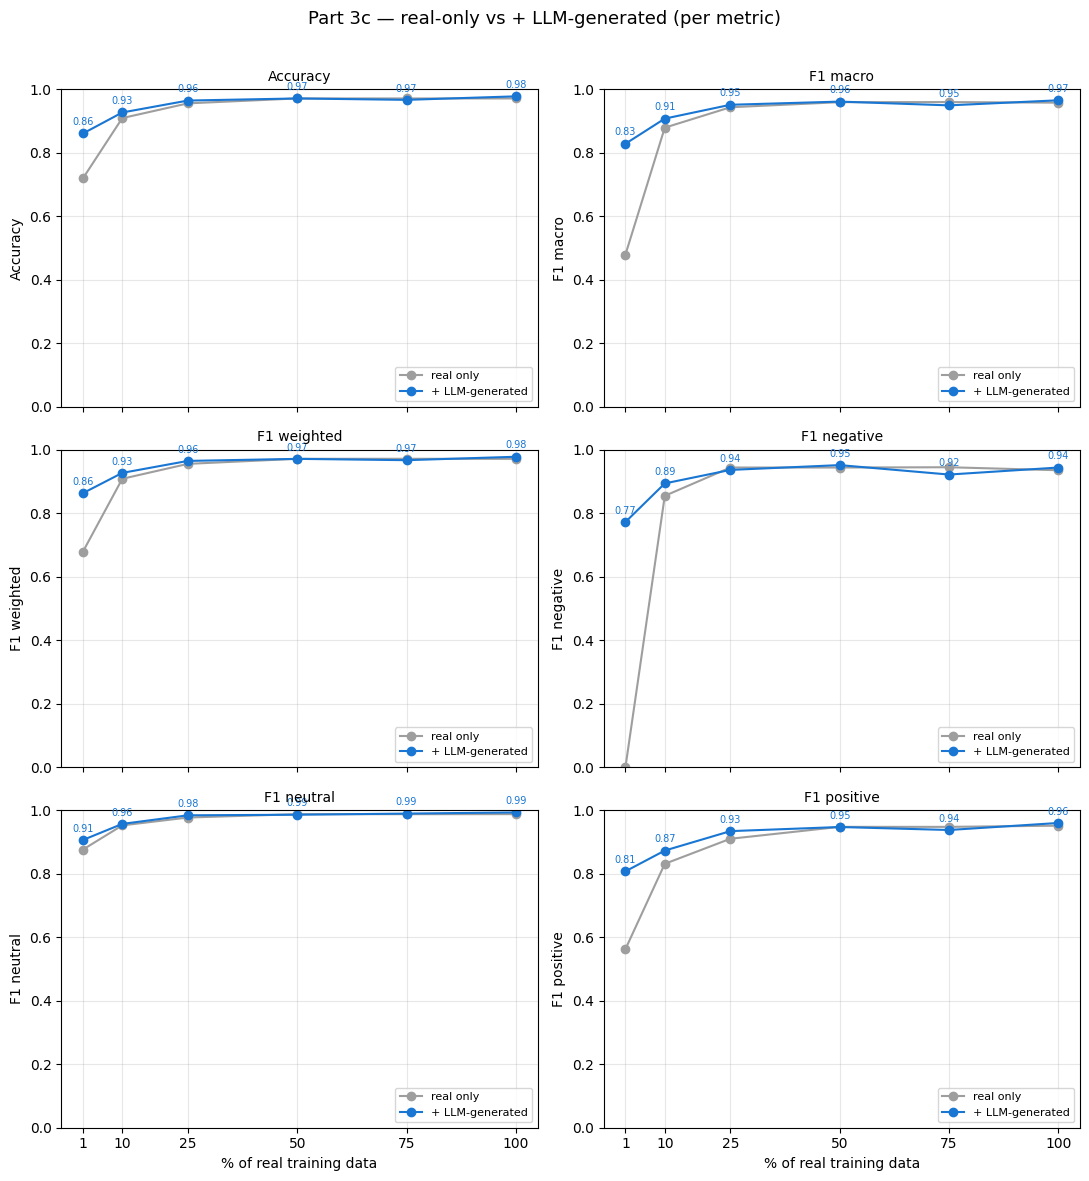

Last run: 2026-06-18 21:10:37


In [10]:
# watermark: AGLLM (AI-assisted content disclosure)
# 3c overlay: the real-only data-scaling curve (3a, 'full-N%') vs the LLM-generated augmented
# curve ('llmgen-N%'), one panel per metric, both vs the % of REAL training data. Reads the
# current-protocol rows from results.csv, so it fills in as the cells above finish.
def plot_curve_overlay(maxlen=None, title='Part 3c — real-only vs + LLM-generated (per metric)'):
    maxlen = str(maxlen if maxlen is not None else CURVE['max_len'])
    res = pd.read_csv(eu.RESULTS_CSV)
    res = res[(res['model'] == MODEL) & (res['split'] == 'test')]
    res = res[res['notes'].apply(lambda s: notes_kv(s).get('maxlen') == maxlen)]

    def series(prefix):
        d = res[res['method'].str.fullmatch(prefix + r'-\d+%').fillna(False)].copy()
        if d.empty:
            return None
        d['pct'] = d['method'].str.extract(r'-(\d+)%')[0].astype(int)
        return d.sort_values('pct')

    base, aug = series('full'), series('llmgen')
    if base is None and aug is None:
        print('[waiting] no logged curve rows yet for this protocol — run 3a and the 3c cell first')
        return
    ticks = (aug if aug is not None else base)['pct'].to_numpy()

    fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True)
    for ax, (key, label) in zip(axes.ravel(), CURVE_METRICS):
        if base is not None:
            ax.plot(base['pct'], base[key].astype(float), marker='o', color='#9e9e9e', label='real only')
        if aug is not None:
            ax.plot(aug['pct'], aug[key].astype(float), marker='o', color='#1976d2', label='+ LLM-generated')
            # value labels on the +LLM-generated points (placed above the marker)
            for x, yy in zip(aug['pct'], aug[key].astype(float)):
                ax.annotate(f'{yy:.2f}', (x, yy), textcoords='offset points',
                            xytext=(0, 6), fontsize=7, ha='center', color='#1976d2')
        ax.set_title(label, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xticks(ticks)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='lower right')   # legend on every panel
    for ax in axes[-1]:
        ax.set_xlabel('% of real training data')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_curve_overlay()

Overall, both models improve as more real data is added, and both end up at a similar level.‍ The clearest difference is at the very start when real data is scarce.‍ The LLM-augmented model is far ahead, but this advantage gradually disappears as the two curves come together at higher percentages.‍

At 1% of the data, the real-only model reaches a macro-F1 of only 0.48 and almost completely fails on the rare negative class.‍ Adding the LLM-generated sentences raises macro-F1 to 0.83 and lifts the negative-class F1 from near zero to 0.77.‍ This gain is roughly as large as the improvement the real-only model gets from moving from 1% to 10% of the data.‍

As more real data becomes available, the gap narrows quickly.‍ The augmented model is about 0.03 higher at 10% and 0.01 higher at 25%, and from 50% onwards the two curves are almost identical, with the augmented model even slightly lower at 75%.‍ 

In short, the LLM-generated data helps most when labelled data is limited, and makes little difference once enough real data is available.‍

## 3d Methodology Analysis

To do the analysis we do:
1.‍ Compare models across all metrics
2.‍ Check sample errors
3.‍ Compare models with SOTA.‍ 

In [11]:
# watermark: AGLLM (AI-assisted content disclosure)
# Reusable Part-2 results chart. plot_metrics(keys) draws all six test metrics in a 3x2
# grid for the given variants, reading results.csv at call time so it always reflects the
# latest logged rows. Variants are sorted by macro-F1 and share that one order across every
# panel, so a given variant sits at the same row in all six -> easy cross-metric scan.
# Regime is shown by colour; the (full)/(probe) tag only disambiguates the BERT variants
# that appear in both regimes.
CHART_VARIANTS = {   # key -> (model, method, short label, regime)
    'random':    ('random-prior',      'baseline',             'Random',             'Baseline'),
    'rule':      ('rule-based',        'baseline',             'Rule-based',         'Baseline'),
    '2a-probe':  ('bert-base-uncased', '32-shot-frozen',       '2a 32-shot (probe)', 'Linear probe'),
    '2b-probe':  ('bert-base-uncased', 'augmented-frozen',     '2b aug (probe)',     'Linear probe'),
    '2d-probe':  ('bert-base-uncased', 'llm-generated-frozen', '2d LLM-gen (probe)', 'Linear probe'),
    '2a-full':   ('bert-base-uncased', '32-shot',              '2a 32-shot (full)',  'Full fine-tune'),
    '2b-full':   ('bert-base-uncased', 'augmented',            '2b aug (full)',      'Full fine-tune'),
    '2d-full':   ('bert-base-uncased', 'llm-generated',        '2d LLM-gen (full)',  'Full fine-tune'),
    '2e-full':   ('bert-base-uncased', 'llm-full',             '2e all-LLM (full)',  'Full fine-tune'),
    '2e-combo':  ('bert-base-uncased', 'llm-bt-combo',         '2e LLM+BT (full)',   'Full fine-tune'),
    'zero-shot': ('claude-opus-4-8',   'zero-shot',            'Zero-shot LLM',      'Zero-shot'),
}
CHART_COLORS = {'Baseline': '#9e9e9e', 'Linear probe': '#ff9800',
                'Full fine-tune': '#1976d2', 'Zero-shot': '#43a047'}
CHART_METRICS = [('accuracy', 'Accuracy'), ('f1_macro', 'F1 macro'),
                 ('f1_weighted', 'F1 weighted'), ('f1_negative', 'F1 negative'),
                 ('f1_neutral', 'F1 neutral'), ('f1_positive', 'F1 positive')]


def plot_metrics(keys, title='Part 2 — test metrics by variant (rows ordered by macro-F1)'):
    """Bar-chart grid of the six test metrics for the given CHART_VARIANTS keys.
    Reads results.csv at call time, so it always reflects the latest logged rows; a key
    with no logged TEST row yet is skipped with a [waiting] note instead of erroring."""
    res = pd.read_csv(eu.RESULTS_CSV)
    res = res[res['split'] == 'test']
    rows = []
    for k in keys:
        model, method, label, regime = CHART_VARIANTS[k]
        hit = res[(res['model'] == model) & (res['method'] == method)]
        if len(hit):
            r = hit.iloc[-1]
            rows.append({'label': label, 'regime': regime,
                         **{mk: float(r[mk]) for mk, _ in CHART_METRICS}})
        else:
            print(f'[waiting] no logged row yet for: {label}')
    if not rows:
        print('[waiting] nothing to plot yet')
        return
    rows.sort(key=lambda d: d['f1_macro'])            # one fixed order shared by every panel
    labels = [d['label'] for d in rows]
    bar_colors = [CHART_COLORS[d['regime']] for d in rows]

    fig, axes = plt.subplots(3, 2, figsize=(12, 11), sharey=True)
    for ax, (mk, mtitle) in zip(axes.ravel(), CHART_METRICS):
        vals = [d[mk] for d in rows]
        ax.barh(labels, vals, color=bar_colors)
        ax.set_xlim(0, 1)
        ax.set_title(mtitle, fontsize=10)
        for y, v in enumerate(vals):
            ax.text(v + 0.01, y, f'{v:.2f}', va='center', fontsize=7)
    present = [rg for rg in CHART_COLORS if any(d['regime'] == rg for d in rows)]
    handles = [plt.Rectangle((0, 0), 1, 1, color=CHART_COLORS[rg]) for rg in present]
    fig.legend(handles, present, loc='lower center', ncol=len(present), fontsize=9)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.show()

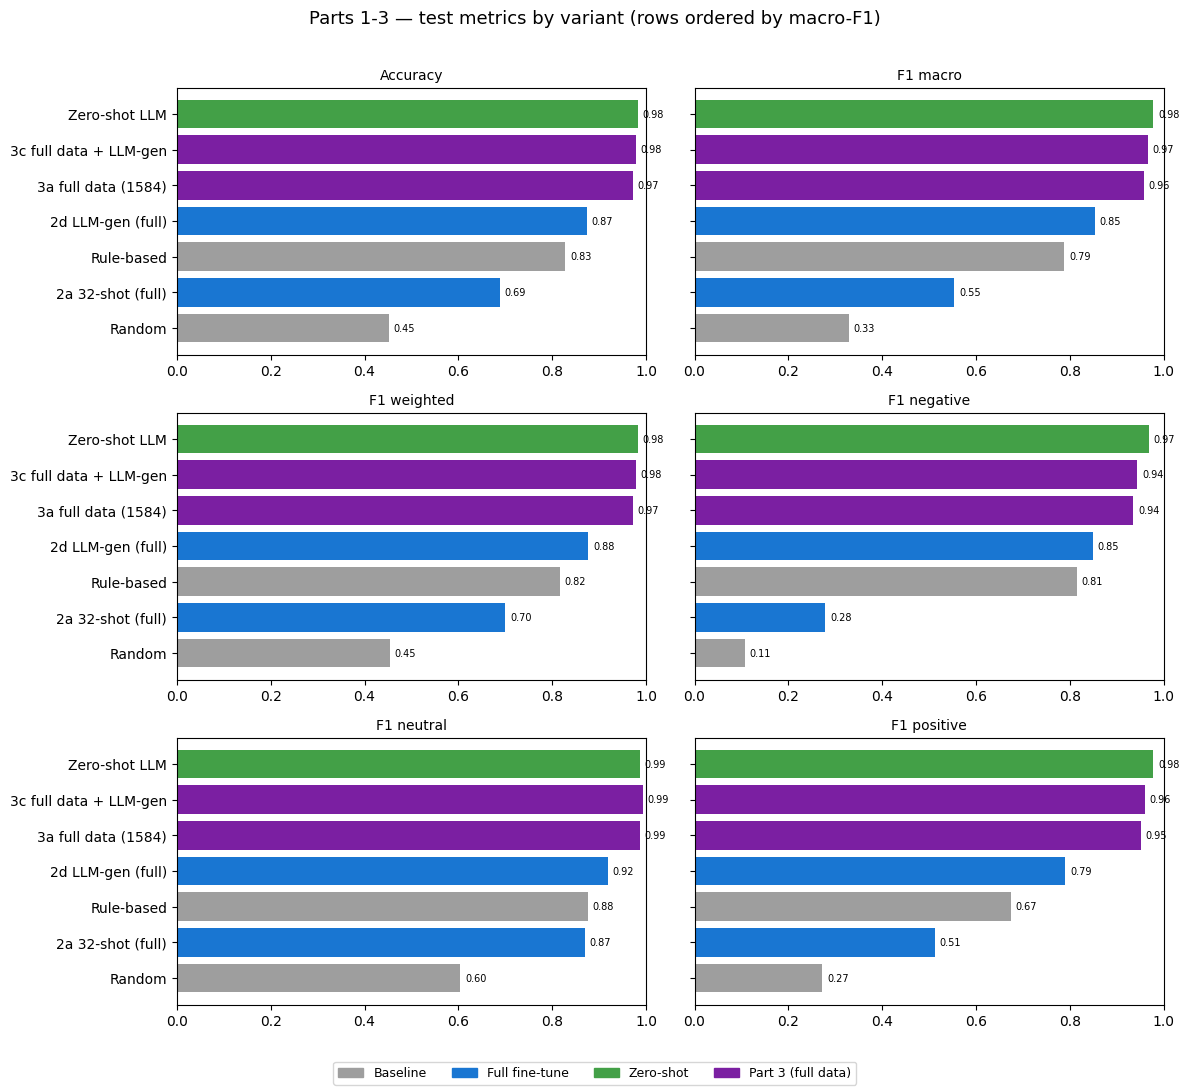

In [12]:
# watermark: AGLLM (AI-assisted content disclosure)
# 3d — add Part 3's representative (full-data) models to the shared comparison chart.
CHART_VARIANTS.update({
    '3a-full': ('bert-base-uncased', 'full-100%',   '3a full data (1584)',     'Part 3 (full data)'),
    '3c-llm':  ('bert-base-uncased', 'llmgen-100%', '3c full data + LLM-gen',  'Part 3 (full data)'),
})
CHART_COLORS['Part 3 (full data)'] = '#7b1fa2'   # purple — sets Part 3 apart from Part 2's bars

# A representative slice across all parts (not every variant): floors -> Part 2 few-shot
# -> Part 3 full data -> zero-shot LLM. plot_metrics auto-sorts rows by macro-F1.
plot_metrics(
    ['random', 'rule',        # Part 1 floors
     '2a-full', '2d-full',    # Part 2 few-shot (32 real, +LLM-generated)
     '3a-full', '3c-llm',     # Part 3 full data
     'zero-shot'],            # LLM reference
    title='Parts 1-3 — test metrics by variant (rows ordered by macro-F1)'
)


1.‍ Review of Performance

We can see that even with the full training set, the fine-tuned BERT from 3a (0.96 macro-F1) still does not overtake the zero-shot LLM (0.98).‍ Part 2 already established that the zero-shot LLM was the single strongest model and discussed its likely benchmark contamination and its cost/latency drawbacks, so we do not repeat that here.‍ 

What we can see from the performane of each class, while zero shot LLM is the best for all, the part 3 models (i.e.‍ full data models) already perform as good as the zero-shot (F1-neutral is 0.99 for the three models).‍ Where the zero shot exceeds is on the positive and negative classes but only by a small margin.‍ 

In comparison to the part 2 models (i.e.‍ 32 and/or augmented data), full data training significantly, on average, improves all metrics by 0.1.‍ If we look back at performance of part 3 models from partial data, we already breached 0.9 performance at 25% of the data for part 3a and at 10% of data for part 3b.‍ These percentages correspond to 396 and 518 observations respectively.‍ So, that ~12x and ~16x more data than 32 observations.‍ What we are seeing is that for this dataset, we do not need a huge amount of data to get high performance.‍ 

In [31]:
# watermark: AGLLM (AI-assisted content disclosure)
# Qualitative error analysis: train the full-data BERT once and inspect correct vs
# incorrect predictions on the test set. (A few minutes on GPU.)
tr_full = train_bert(train, '../.cache/bert_examples', lr=2e-5, **CURVE)
pred = tr_full.predict(encode(test, CURVE['max_len'])).predictions.argmax(-1)

names = du.LABEL_NAMES
ex = test[['text', 'label']].copy()
ex['true'] = ex['label'].map(lambda i: names[i])
ex['pred'] = [names[p] for p in pred]
ex['ok']   = ex['label'].values == pred

pd.set_option('display.max_colwidth', 100)
print(f"test accuracy: {ex['ok'].mean():.3f}  ({ex['ok'].sum()}/{len(ex)} correct)")
print('\n--- 5 correct predictions ---')
display(ex[ex['ok']].sample(5, random_state=SEED)[['text', 'true', 'pred']])
print('\n--- 5 incorrect predictions ---')
display(ex[~ex['ok']].sample(5, random_state=SEED)[['text', 'true', 'pred']])


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,No log,0.162211,0.942731,0.904004,0.943230,0.825397,0.985714,0.900901
2,No log,0.218326,0.947137,0.920051,0.948295,0.861538,0.978261,0.920354
3,No log,0.267821,0.951542,0.924034,0.950242,0.872727,0.979021,0.920354
4,No log,0.306609,0.947137,0.928864,0.948188,0.906250,0.974359,0.905983
5,No log,0.159470,0.969163,0.947800,0.969558,0.903226,0.992806,0.947368
6,No log,0.263262,0.942731,0.926717,0.944122,0.915254,0.970588,0.894309
7,No log,0.238411,0.960352,0.934736,0.959798,0.881356,0.985915,0.936937
8,No log,0.161620,0.973568,0.953939,0.973741,0.918033,0.996416,0.947368
9,No log,0.193241,0.964758,0.943245,0.964364,0.896552,0.985816,0.947368
10,No log,0.327846,0.947137,0.934950,0.948446,0.931034,0.970588,0.903226


test accuracy: 0.974  (441/453 correct)

--- 5 correct predictions ---


,text,true,pred
79,SKF 6 April 2010 - Alandsbanken has given a `` buy '' recommendation on Swedish industrial compa...,positive,positive
450,"In the building and home improvement trade , sales decreased by 6.3 % , totalling EUR 154.1 mn .",negative,negative
156,"Excluding non-recurring items , pre-tax profit surged 45 % to EUR80m .",positive,positive
288,The intent of the article was to focus attention on the fact that the development model that Chi...,neutral,neutral
403,"Finnair 's passenger load factor , which measures the number of sold seats as a share of all ava...",negative,negative



--- 5 incorrect predictions ---


,text,true,pred
417,"Making matters more difficult , the company said it has been grappling with higher oil and gas p...",negative,positive
414,"29 September , 2010 Finnish waste management and recycling company Lassila & Tikanoja expands it...",positive,neutral
61,Unit costs for flight operations fell by 6.4 percent .,positive,negative
375,Finnish technology company Raute Corporation ( OMX Helsinki : RUTAV ) issued on Tuesday ( 23 Sep...,negative,neutral
166,"Pre-tax loss totaled EUR 0.3 mn , compared to a loss of EUR 2.2 mn in the first quarter of 2005 .",positive,negative


In [12]:
# watermark: AGLLM (AI-assisted content disclosure)
# Full (untruncated) text of the 5 correct / 5 incorrect rows shown in the table above.
# `ex` is no longer in memory, so we pull the text straight from `test` by the index numbers
# from that output; (true, pred) labels are copied from the same table so no model is needed.
correct = [(79, 'positive', 'positive'), (450, 'negative', 'negative'),
           (156, 'positive', 'positive'), (288, 'neutral',  'neutral'),
           (403, 'negative', 'negative')]
incorrect = [(417, 'negative', 'positive'), (414, 'positive', 'neutral'),
             (61,  'positive', 'negative'), (375, 'negative', 'neutral'),
             (166, 'positive', 'negative')]

def show_full(rows, header):
    print(header)
    for idx, true, pred in rows:
        print(f"\n[{idx}]  true={true}  pred={pred}")
        print(test.loc[idx, 'text'])
    print()

show_full(correct,   '=== 5 correct predictions (full text) ===')
show_full(incorrect, '=== 5 incorrect predictions (full text) ===')


=== 5 correct predictions (full text) ===

[79]  true=positive  pred=positive
SKF 6 April 2010 - Alandsbanken has given a `` buy '' recommendation on Swedish industrial company SKF AB ( STO : SKF B ) with a share price target of SEK150 .

[450]  true=negative  pred=negative
In the building and home improvement trade , sales decreased by 6.3 % , totalling EUR 154.1 mn .

[156]  true=positive  pred=positive
Excluding non-recurring items , pre-tax profit surged 45 % to EUR80m .

[288]  true=neutral  pred=neutral
The intent of the article was to focus attention on the fact that the development model that China had followed was very different than the model that India had followed .

[403]  true=negative  pred=negative
Finnair 's passenger load factor , which measures the number of sold seats as a share of all available seats , dropped by 1.3 percentage points to 76.7 % in September .

=== 5 incorrect predictions (full text) ===

[417]  true=negative  pred=positive
Making matters more diffi

2.‍ Review of Errors

The full-data model (BERT tuned on 100% of the data) classifies 441 of the 453 test sentences correctly (97.4% accuracy), so only twelve are wrong, and the correct examples span all three classes.‍

On the correctly classified sample, the model handles cases where sentiment follows directly from a financial word and its direction — "pre-tax profit surged 45%" is read as positive, "sales decreased by 6.3%" as negative.‍

The errors come from two situations.‍ The first is when the financial direction reverses the surface word.‍ "Unit costs for flight operations fell by 6.4 percent" is positive (falling costs are good news), but the model predicts negative, anchored on "fell".‍ The second is when there is no explicit directional word at all.‍ "Pre-tax loss totaled EUR 0.3 mn, compared to a loss of EUR 2.2 mn" is positive because the loss has shrunk, but the model predicts negative on "loss", with no word like "decreased" to signal direction.‍ A related case is non-directional sentiment: for "Finnish technology company Raute Corporation ( OMX Helsinki : RUTAV ) issued on Tuesday ( 23 September ) a profit warning for the financial year 2008" the true label is negative, but with no directional cue the model defaults to neutral.‍

In short, the model fails when sentiment is not a simple function of a financial word and its direction.‍ These are the cases that need broader context to resolve, which is where the zero-shot LLM has the advantage.‍

3.‍ Comparison with the SOTA

| Model | Macro-F1 | Weighted-F1 |
|---|---|---|
| **Ours — BERT `llmgen-100%`** | **0.97** | **0.98** |
| **Ours — BERT `full-100%`** | **0.96** | **0.97** |
| FinBERT (Araci, 2019) | 0.95 | — |
| EnhancedFinSentiBERT (Sun et al., 2025) | — | 0.98 |

Our models are comparable with SOTA, and even edge past the published FinBERT, which adds financial-domain pre-training on top of BERT that our plain `bert-base-uncased` does not have.‍ Note that we may not be using the same test split, so a gap this small could be down to randomness.‍

More interesting, if we treat the results as indicative, is that BERT trained on the full 100% with LLM-augmented data essentially matches EnhancedFinSentiBERT — itself an improvement over FinBERT through dictionary knowledge and neutral features.‍ This suggests that the gain EnhancedFinSentiBERT gets from those hand-built financial features may be captured here by the LLM-augmented data instead.‍